# Laboratorio #5 - Ejercicio 3
## Módulo de desarrollo: funciones para interactuar con ALE

### Entorno de ejecución

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py

from ale_utils import (
    crear_entorno,
    agente_aleatorio,
    agente_regla_simple,
    ejecutar_episodio,
    generar_video_agente,
)

print("Python    :", sys.version.split()[0])
print("Gymnasium :", gym.__version__)
print("ale-py    :", ale_py.__version__)
print("NumPy     :", np.__version__)

Python    : 3.9.6
Gymnasium : 1.1.1
ale-py    : 0.11.2
NumPy     : 2.0.2


## 1. `crear_entorno`

In [2]:
import tempfile

# a) Entorno de Atari por defecto: ALE/SpaceInvaders-v5
env = crear_entorno()
print("ALE/SpaceInvaders-v5")
print("  observation_space:", env.observation_space)
print("  action_space     :", env.action_space)
print("  acciones         :", env.unwrapped.get_action_meanings())
env.close()

# b) Variante con observación en RAM y parámetros propios de ALE
env = crear_entorno(obs_type="ram", frameskip=1, repeat_action_probability=0.0)
print("\nVariante RAM (obs_type='ram', frameskip=1, repeat_action_probability=0.0)")
print("  observation_space:", env.observation_space)
env.close()

# c) Cualquier otro entorno de Gymnasium
env = crear_entorno("CartPole-v1", render_mode=None)
print("\nCartPole-v1")
print("  observation_space:", env.observation_space)
print("  action_space     :", env.action_space)
env.close()

# d) Con grabación de video habilitada
env = crear_entorno(video_folder=tempfile.mkdtemp(), name_prefix="demo")
print("\nCon video_folder")
print("  wrapper          :", type(env).__name__)
print("  render_mode      :", env.render_mode, "(forzado a rgb_array)")
env.close()

ALE/SpaceInvaders-v5
  observation_space: Box(0, 255, (210, 160, 3), uint8)
  action_space     : Discrete(6)
  acciones         : ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']

Variante RAM (obs_type='ram', frameskip=1, repeat_action_probability=0.0)
  observation_space: Box(0, 255, (128,), uint8)

CartPole-v1
  observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  action_space     : Discrete(2)

Con video_folder
  wrapper          : RecordVideo
  render_mode      : rgb_array (forzado a rgb_array)


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/Users/marinesgarcia/Documents/UVG/DL/venv/lib/python3.9/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /var/folders/ls/r_brwh_14l54j3kt17qt0xl80000gn/T/tmpfipa5di8 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## 2. `agente_aleatorio`

In [3]:
from collections import Counter

env = crear_entorno()
obs, _ = env.reset(seed=0)
env.action_space.seed(0)

N = 6000
acciones = [agente_aleatorio(obs, env) for _ in range(N)]
nombres = env.unwrapped.get_action_meanings()

print(f"Distribución de {N} acciones muestreadas (esperado: uniforme, 1/6 = 16.7%)")
for a, cuenta in sorted(Counter(acciones).items()):
    print(f"  {a}  {nombres[a]:<10} {cuenta:5d}  ({cuenta / N:.1%})")

print("\nTodas las acciones son válidas:",
      all(env.action_space.contains(a) for a in acciones))
env.close()

Distribución de 6000 acciones muestreadas (esperado: uniforme, 1/6 = 16.7%)
  0  NOOP        1017  (17.0%)
  1  FIRE         970  (16.2%)
  2  RIGHT       1006  (16.8%)
  3  LEFT        1008  (16.8%)
  4  RIGHTFIRE    969  (16.2%)
  5  LEFTFIRE    1030  (17.2%)

Todas las acciones son válidas: True


## 3. `agente_regla_simple`

Cañón detectado en x = 37.0
Columnas con invasores encima: 72 | columnas libres: 48
Hueco más cercano: x = 43  ->  acción RIGHTFIRE


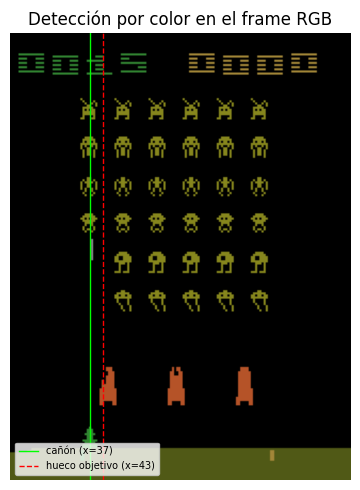

In [4]:
from ale_utils import (_columnas_de_color, COLOR_JUGADOR, COLOR_ALIENS,
                       FILAS_JUGADOR, MARGEN_ALIEN, X_MIN_CANON, X_MAX_CANON)

env = crear_entorno()
obs, _ = env.reset(seed=0)
for _ in range(120):                      # dejar que arranque la partida
    obs, *_ = env.step(1)

x_jugador = _columnas_de_color(obs, COLOR_JUGADOR, FILAS_JUGADOR)
x_aliens = _columnas_de_color(obs, COLOR_ALIENS)
centro = x_jugador.mean()
ocupadas = np.concatenate([x_aliens + k for k in range(-MARGEN_ALIEN, MARGEN_ALIEN + 1)])
libres = np.setdiff1d(np.arange(X_MIN_CANON, X_MAX_CANON), ocupadas)
objetivo = libres[np.argmin(np.abs(libres - centro))]

print(f"Cañón detectado en x = {centro:.1f}")
print(f"Columnas con invasores encima: {len(np.unique(ocupadas))} | columnas libres: {len(libres)}")
print(f"Hueco más cercano: x = {objetivo}  ->  acción "
      f"{env.unwrapped.get_action_meanings()[agente_regla_simple(obs, env)]}")

fig, ax = plt.subplots(figsize=(4, 5))
ax.imshow(obs)
ax.axvline(centro, color="lime", lw=1, label=f"cañón (x={centro:.0f})")
ax.axvline(objetivo, color="red", lw=1, ls="--", label=f"hueco objetivo (x={objetivo})")
ax.set_title("Detección por color en el frame RGB")
ax.legend(fontsize=7, loc="lower left")
ax.axis("off")
plt.tight_layout()
plt.savefig("deteccion_regla_simple.png", dpi=150)
plt.show()
env.close()

In [5]:
# Distribución de acciones que elige la regla durante una partida
env = crear_entorno()
obs, _ = env.reset(seed=0)
nombres = env.unwrapped.get_action_meanings()

conteo = Counter()
for _ in range(800):
    accion = agente_regla_simple(obs, env)
    conteo[nombres[accion]] += 1
    obs, reward, terminated, truncated, _ = env.step(accion)
    if terminated or truncated:
        break

print("Acciones elegidas por la regla simple:", dict(conteo))
env.close()

Acciones elegidas por la regla simple: {'FIRE': 766, 'LEFTFIRE': 20, 'RIGHTFIRE': 14}


## 4. `ejecutar_episodio`

In [6]:
env = crear_entorno()

print("=== Agente aleatorio ===")
res_aleatorio = ejecutar_episodio(env, agente_aleatorio, seed=0, verbose=True)

print("\n=== Agente de regla simple ===")
res_regla = ejecutar_episodio(env, agente_regla_simple, seed=0, verbose=True)

env.close()

print("\nContenido del diccionario retornado (agente aleatorio):")
for clave, valor in res_aleatorio.items():
    if clave == "recompensas":
        valor = f"lista de {len(valor)} recompensas, {valor[:8]} ..."
    print(f"  {clave:18s}: {valor}")

=== Agente aleatorio ===
Episodio finalizado (terminated): pasos=298, recompensa_total=35.0

=== Agente de regla simple ===


Episodio finalizado (terminated): pasos=1121, recompensa_total=435.0

Contenido del diccionario retornado (agente aleatorio):
  pasos             : 298
  recompensa_total  : 35.0
  terminated        : True
  truncated         : False
  motivo_fin        : terminated
  recompensas       : lista de 298 recompensas, [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] ...
  info              : {'lives': 0, 'episode_frame_number': 1189, 'frame_number': 1189}


## 5. `generar_video_agente`

### 5.1 Agente aleatorio en ALE/SpaceInvaders-v5

In [7]:
resultado_aleatorio = generar_video_agente(
    nombre_entorno="ALE/SpaceInvaders-v5",
    funcion_agente=agente_aleatorio,
    video_folder="videos",
    name_prefix="aleatorio",
    n_episodios=3,
    seed=0,
)

Episodio 1/3 (terminated): pasos=298, recompensa_total=35.0


/Users/marinesgarcia/Documents/UVG/DL/venv/lib/python3.9/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/marinesgarcia/Documents/UVG/DL/lab5-DL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episodio 2/3 (terminated): pasos=493, recompensa_total=155.0

Episodio 3/3 (terminated): pasos=522, recompensa_total=150.0



Videos generados en /Users/marinesgarcia/Documents/UVG/DL/lab5-DL/videos:
  - aleatorio-episode-0.mp4
  - aleatorio-episode-1.mp4
  - aleatorio-episode-2.mp4
Recompensa promedio: 113.3 | Pasos promedio: 437.7


### 5.2 Agente de regla simple en ALE/SpaceInvaders-v5

In [8]:
resultado_regla = generar_video_agente(
    nombre_entorno="ALE/SpaceInvaders-v5",
    funcion_agente=agente_regla_simple,
    video_folder="videos",
    name_prefix="regla_simple",
    n_episodios=3,
    seed=0,
)

Episodio 1/3 (terminated): pasos=1121, recompensa_total=435.0


Episodio 2/3 (terminated): pasos=1121, recompensa_total=655.0


Episodio 3/3 (terminated): pasos=1121, recompensa_total=210.0

Videos generados en /Users/marinesgarcia/Documents/UVG/DL/lab5-DL/videos:
  - regla_simple-episode-0.mp4
  - regla_simple-episode-1.mp4
  - regla_simple-episode-2.mp4
Recompensa promedio: 433.3 | Pasos promedio: 1121.0


## 6. Resultados: pasos sobrevividos y recompensa por video

In [9]:
import os

filas = []
for etiqueta, resultado in [("aleatorio", resultado_aleatorio),
                            ("regla simple", resultado_regla)]:
    for ruta, ep in zip(resultado["videos"], resultado["episodios"]):
        filas.append((os.path.basename(ruta), etiqueta, ep["seed"],
                      ep["pasos"], ep["recompensa_total"], ep["motivo_fin"]))

encabezado = f"{'video':28s} {'agente':13s} {'seed':>4s} {'pasos':>6s} {'recompensa':>11s}  fin"
print(encabezado)
print("-" * len(encabezado))
for video, agente, seed, pasos, recompensa, fin in filas:
    print(f"{video:28s} {agente:13s} {seed:4d} {pasos:6d} {recompensa:11.1f}  {fin}")

print(f"\nAleatorio    -> recompensa promedio {resultado_aleatorio['recompensa_promedio']:6.1f} | "
      f"pasos promedio {resultado_aleatorio['pasos_promedio']:7.1f}")
print(f"Regla simple -> recompensa promedio {resultado_regla['recompensa_promedio']:6.1f} | "
      f"pasos promedio {resultado_regla['pasos_promedio']:7.1f}")

video                        agente        seed  pasos  recompensa  fin
-----------------------------------------------------------------------
aleatorio-episode-0.mp4      aleatorio        0    298        35.0  terminated
aleatorio-episode-1.mp4      aleatorio        1    493       155.0  terminated
aleatorio-episode-2.mp4      aleatorio        2    522       150.0  terminated
regla_simple-episode-0.mp4   regla simple     0   1121       435.0  terminated
regla_simple-episode-1.mp4   regla simple     1   1121       655.0  terminated
regla_simple-episode-2.mp4   regla simple     2   1121       210.0  terminated

Aleatorio    -> recompensa promedio  113.3 | pasos promedio   437.7
Regla simple -> recompensa promedio  433.3 | pasos promedio  1121.0


### Vista previa del video del agente aleatorio

aleatorio-episode-0.mp4: 298 frames | 30.0 fps | (160, 210) px | 9.9 s


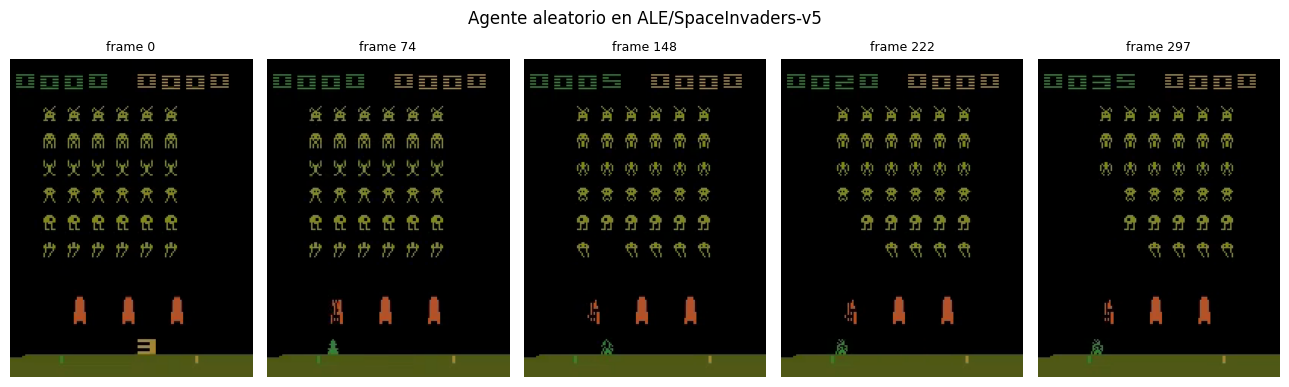

In [10]:
import imageio

ruta_video = resultado_aleatorio["videos"][0]
lector = imageio.get_reader(ruta_video, "ffmpeg")
meta = lector.get_meta_data()
total_frames = lector.count_frames()
print(f"{os.path.basename(ruta_video)}: {total_frames} frames | {meta['fps']} fps | "
      f"{meta['size']} px | {meta['duration']:.1f} s")

indices = np.linspace(0, total_frames - 1, 5, dtype=int)
fig, axes = plt.subplots(1, len(indices), figsize=(13, 4))
for ax, i in zip(axes, indices):
    ax.imshow(lector.get_data(int(i)))
    ax.set_title(f"frame {i}", fontsize=9)
    ax.axis("off")
lector.close()
fig.suptitle("Agente aleatorio en ALE/SpaceInvaders-v5")
plt.tight_layout()
plt.savefig("frames_agente_aleatorio.png", dpi=150)
plt.show()

## 7. Comparación de agentes sobre varios episodios

In [11]:
N_EPISODIOS = 10

def evaluar(funcion_agente, n_episodios=N_EPISODIOS):
    """Corre n_episodios completos y retorna (pasos, recompensas) por episodio."""
    env = crear_entorno(render_mode=None)
    pasos, recompensas = [], []
    for i in range(n_episodios):
        res = ejecutar_episodio(env, funcion_agente, seed=i)
        pasos.append(res["pasos"])
        recompensas.append(res["recompensa_total"])
    env.close()
    return np.array(pasos), np.array(recompensas)

pasos_al, rec_al = evaluar(agente_aleatorio)
pasos_rs, rec_rs = evaluar(agente_regla_simple)

print(f"{'agente':14s} {'recompensa media':>17s} {'desv':>7s} {'min':>6s} {'max':>6s} {'pasos medios':>13s}")
for nombre, pasos, rec in [("aleatorio", pasos_al, rec_al), ("regla simple", pasos_rs, rec_rs)]:
    print(f"{nombre:14s} {rec.mean():17.1f} {rec.std():7.1f} {rec.min():6.0f} "
          f"{rec.max():6.0f} {pasos.mean():13.1f}")

agente          recompensa media    desv    min    max  pasos medios
aleatorio                  123.5    69.5     30    235         461.0
regla simple               367.5   173.1    185    665        1121.0


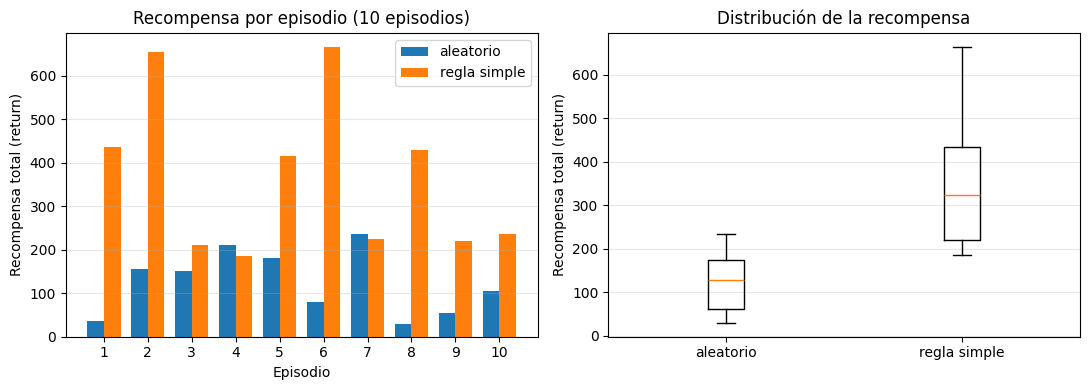

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

x = np.arange(1, N_EPISODIOS + 1)
ancho = 0.38
ax1.bar(x - ancho / 2, rec_al, ancho, label="aleatorio")
ax1.bar(x + ancho / 2, rec_rs, ancho, label="regla simple")
ax1.set_xlabel("Episodio")
ax1.set_ylabel("Recompensa total (return)")
ax1.set_title(f"Recompensa por episodio ({N_EPISODIOS} episodios)")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

ax2.boxplot([rec_al, rec_rs], tick_labels=["aleatorio", "regla simple"])
ax2.set_ylabel("Recompensa total (return)")
ax2.set_title("Distribución de la recompensa")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("comparacion_agentes.png", dpi=150)
plt.show()

## 8. Conclusiones del ejercicio

**El módulo funciona de extremo a extremo.** Las cinco funciones (`crear_entorno`, `agente_aleatorio`, `agente_regla_simple`, `ejecutar_episodio`, `generar_video_agente`) permiten crear el entorno, correr un agente sin entrenamiento y dejar el video escrito en disco con una sola llamada. Se generaron 6 videos en [`videos/`](videos): 3 del agente aleatorio y 3 del agente de regla simple, todos de episodios **completos** (`motivo_fin = "terminated"`).

**Videos entregados** (pasos sobrevividos y recompensa total de cada episodio):

| Video | Agente | Seed | Pasos | Recompensa |
|---|---|---:|---:|---:|
| `aleatorio-episode-0.mp4` | aleatorio | 0 | 298 | 35 |
| `aleatorio-episode-1.mp4` | aleatorio | 1 | 493 | 155 |
| `aleatorio-episode-2.mp4` | aleatorio | 2 | 522 | 150 |
| `regla_simple-episode-0.mp4` | regla simple | 0 | 1121 | 435 |
| `regla_simple-episode-1.mp4` | regla simple | 1 | 1121 | 655 |
| `regla_simple-episode-2.mp4` | regla simple | 2 | 1121 | 210 |

**La heurística supera claramente al baseline aleatorio.** Sobre 10 episodios, la regla simple obtiene 367.5 puntos de recompensa media contra 123.5 del agente aleatorio (≈3×) y sobrevive 1121 pasos contra 461 (≈2.4×). Aun así, su varianza es alta (desviación de 173.1 puntos, entre 185 y 665), porque el resultado depende mucho de cuántos invasores alcance a derribar antes de que la formación descienda.

**Todos los episodios de la regla simple terminan exactamente en el paso 1121** (frame 4481) con `lives = 0`, sin importar la semilla ni la puntuación obtenida. La interpretación es que este agente casi nunca muere por las bombas enemigas —al mantenerse en los huecos entre columnas evita la línea de tiro—, así que la partida no la termina el agente sino el descenso de la formación de invasores, que ocurre a un ritmo fijo. En cambio el agente aleatorio muere antes, y por eso su duración sí varía entre episodios (298 a 522 pasos en los videos grabados).

**Una heurística "obvia" puede ser peor que el azar.** La primera versión de la regla consistía en alinearse con el alien más cercano y disparar; obtuvo apenas 63 puntos de media contra 116 del agente aleatorio, porque perseguir a los invasores saca al cañón de la cobertura de los escudos y lo deja expuesto (moría alrededor del paso 390). Fue necesario cambiar el criterio a "buscar un hueco" para que la regla superara al baseline: sin una medición sistemática contra el agente aleatorio, la intuición sobre qué política es mejor resultó equivocada.

**Los resultados son reproducibles.** `ejecutar_episodio` siembra tanto `env.reset(seed=...)` como `env.action_space.seed(...)` —el espacio de acciones tiene su propio generador aleatorio, independiente del entorno—, de modo que volver a ejecutar el notebook reproduce exactamente los mismos pasos, recompensas y videos.

**Reutilización en el Proyecto 2.** Como todas las funciones son agnósticas al entorno (se probaron también con `CartPole-v1` y con la variante `obs_type="ram"`) y el contrato del agente es siempre `(observation, env) -> action`, para evaluar y grabar la política entrenada bastará con reemplazar `funcion_agente` por la red de la política, sin tocar el resto del módulo.